In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
df = pd.read_csv('../patient2025 - patient2025.csv')
df.head()

,HN,FBS,BMI,Diabetes,Chorestorol,age,hypertension,"vegetarian (1= yes, 0=no)",Marriage Status,Exercise (min/week),Living Area,stroke
0,11223,228.69,34.0,yes,201-220,71.0,1,1,Yes,0.0,Bangkok,1
1,8887,202.21,NaN,No,180-200,52.0,1,0,Yes,90.0,Country,1
2,5666,105.92,30.5,yes,180-200,78.0,1,1,Yes,0.0,Country,1
3,460182,171.23,35.0,No,221-260,54.0,1,0,Yes,0.0,Bangkok,1
4,166665,174.12,28.0,No,180-200,79.0,1,0,Yes,90.0,Country,1


In [3]:
df.set_index('HN', inplace=True)
df.head()

,FBS,BMI,Diabetes,Chorestorol,age,hypertension,"vegetarian (1= yes, 0=no)",Marriage Status,Exercise (min/week),Living Area,stroke
HN,,,,,,,,,,,
11223,228.69,34.0,yes,201-220,71.0,1,1,Yes,0.0,Bangkok,1
8887,202.21,NaN,No,180-200,52.0,1,0,Yes,90.0,Country,1
5666,105.92,30.5,yes,180-200,78.0,1,1,Yes,0.0,Country,1
460182,171.23,35.0,No,221-260,54.0,1,0,Yes,0.0,Bangkok,1
166665,174.12,28.0,No,180-200,79.0,1,0,Yes,90.0,Country,1


# Preprocessing Data

## กำจัด field ที่ไม่ใช้

In [4]:
df = df.drop(columns=['Marriage Status', 'Living Area'])
df

,FBS,BMI,Diabetes,Chorestorol,age,hypertension,"vegetarian (1= yes, 0=no)",Exercise (min/week),stroke
HN,,,,,,,,,
11223,228.69,34.0,yes,201-220,71.00,1,1,0.0,1
8887,202.21,NaN,No,180-200,52.00,1,0,90.0,1
5666,105.92,30.5,yes,180-200,78.00,1,1,0.0,1
460182,171.23,35.0,No,221-260,54.00,1,0,0.0,1
166665,174.12,28.0,No,180-200,79.00,1,0,90.0,1
...,...,...,...,...,...,...,...,...,...
60211,90.51,18.9,yes,Unknown,1.40,0,0,120.0,0
53279,118.87,16.3,yes,Unknown,0.24,0,0,120.0,0
61715,56.42,31.8,yes,180-200,55.00,0,0,0.0,0


## กำจัดค่า Nan

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 11223 to 2454
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   FBS                        1000 non-null   float64
 1   BMI                        940 non-null    float64
 2   Diabetes                   1000 non-null   object 
 3   Chorestorol                1000 non-null   object 
 4   age                        1000 non-null   float64
 5   hypertension               1000 non-null   int64  
 6   vegetarian (1= yes, 0=no)  1000 non-null   int64  
 7   Exercise (min/week)        974 non-null    float64
 8   stroke                     1000 non-null   int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 78.1+ KB


In [6]:
df = df.fillna(0)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 11223 to 2454
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   FBS                        1000 non-null   float64
 1   BMI                        1000 non-null   float64
 2   Diabetes                   1000 non-null   object 
 3   Chorestorol                1000 non-null   object 
 4   age                        1000 non-null   float64
 5   hypertension               1000 non-null   int64  
 6   vegetarian (1= yes, 0=no)  1000 non-null   int64  
 7   Exercise (min/week)        1000 non-null   float64
 8   stroke                     1000 non-null   int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 78.1+ KB


## กำจัดค่า Unknown ใน Chorestorol

In [7]:
df.loc[df['Chorestorol'] == 'Unknown', 'Chorestorol'] = '0-0'
df

,FBS,BMI,Diabetes,Chorestorol,age,hypertension,"vegetarian (1= yes, 0=no)",Exercise (min/week),stroke
HN,,,,,,,,,
11223,228.69,34.0,yes,201-220,71.00,1,1,0.0,1
8887,202.21,0.0,No,180-200,52.00,1,0,90.0,1
5666,105.92,30.5,yes,180-200,78.00,1,1,0.0,1
460182,171.23,35.0,No,221-260,54.00,1,0,0.0,1
166665,174.12,28.0,No,180-200,79.00,1,0,90.0,1
...,...,...,...,...,...,...,...,...,...
60211,90.51,18.9,yes,0-0,1.40,0,0,120.0,0
53279,118.87,16.3,yes,0-0,0.24,0,0,120.0,0
61715,56.42,31.8,yes,180-200,55.00,0,0,0.0,0


## แปลงค่า Chorestorol จากเป็นช่วงเป็นค่ากลางแทน

In [8]:
df['Chorestorol'] = df['Chorestorol'].str.split('-')
df['Chorestorol'] = (df['Chorestorol'].str[0].astype(int) + df['Chorestorol'].str[1].astype(int)) / 2 

df

,FBS,BMI,Diabetes,Chorestorol,age,hypertension,"vegetarian (1= yes, 0=no)",Exercise (min/week),stroke
HN,,,,,,,,,
11223,228.69,34.0,yes,210.5,71.00,1,1,0.0,1
8887,202.21,0.0,No,190.0,52.00,1,0,90.0,1
5666,105.92,30.5,yes,190.0,78.00,1,1,0.0,1
460182,171.23,35.0,No,240.5,54.00,1,0,0.0,1
166665,174.12,28.0,No,190.0,79.00,1,0,90.0,1
...,...,...,...,...,...,...,...,...,...
60211,90.51,18.9,yes,0.0,1.40,0,0,120.0,0
53279,118.87,16.3,yes,0.0,0.24,0,0,120.0,0
61715,56.42,31.8,yes,190.0,55.00,0,0,0.0,0


## แปลง Diabetes จาก yes/No เป็น 0/1

In [9]:
df.loc[df['Diabetes'] == 'yes', 'Diabetes'] = 1
df.loc[df['Diabetes'] == 'No', 'Diabetes'] = 0

df

,FBS,BMI,Diabetes,Chorestorol,age,hypertension,"vegetarian (1= yes, 0=no)",Exercise (min/week),stroke
HN,,,,,,,,,
11223,228.69,34.0,1,210.5,71.00,1,1,0.0,1
8887,202.21,0.0,0,190.0,52.00,1,0,90.0,1
5666,105.92,30.5,1,190.0,78.00,1,1,0.0,1
460182,171.23,35.0,0,240.5,54.00,1,0,0.0,1
166665,174.12,28.0,0,190.0,79.00,1,0,90.0,1
...,...,...,...,...,...,...,...,...,...
60211,90.51,18.9,1,0.0,1.40,0,0,120.0,0
53279,118.87,16.3,1,0.0,0.24,0,0,120.0,0
61715,56.42,31.8,1,190.0,55.00,0,0,0.0,0


## ทำ MinMaxScaler เพื่อให้ในแต่ละ Node มีค่าตั้งแต่ 0-1

In [10]:
features = ['FBS', 'BMI',	'Diabetes', 'Chorestorol', 'age', 'hypertension',	'vegetarian (1= yes, 0=no)',	'Exercise (min/week)']
df.loc[df.index, features] = MinMaxScaler().fit_transform(df[features])

df

,FBS,BMI,Diabetes,Chorestorol,age,hypertension,"vegetarian (1= yes, 0=no)",Exercise (min/week),stroke
HN,,,,,,,,,
11223,0.801146,0.435897,1.0,0.875260,0.806290,1,1,0.00,1
8887,0.678830,0.000000,0.0,0.790021,0.589790,1,0,0.75,1
5666,0.234052,0.391026,1.0,0.790021,0.886053,1,1,0.00,1
460182,0.535729,0.448718,0.0,1.000000,0.612580,1,0,0.00,1
166665,0.549078,0.358974,0.0,0.790021,0.897448,1,0,0.75,1
...,...,...,...,...,...,...,...,...,...
60211,0.162871,0.242308,1.0,0.000000,0.013218,0,0,1.00,0
53279,0.293870,0.208974,1.0,0.000000,0.000000,0,0,1.00,0
61715,0.005404,0.407692,1.0,0.790021,0.623974,0,0,0.00,0


# Start Training

In [11]:
X = df[features]
y = df['stroke']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

In [13]:
X_test

,FBS,BMI,Diabetes,Chorestorol,age,hypertension,"vegetarian (1= yes, 0=no)",Exercise (min/week)
HN,,,,,,,,
34511,0.209525,0.246154,0.0,0.000000,0.806290,0,0,0.0
7663,0.238902,0.357692,1.0,0.875260,0.225160,0,0,0.5
23221,0.130537,0.475641,1.0,0.790021,0.327712,0,0,0.0
9404,0.240935,0.606410,0.0,0.790021,0.498633,0,0,0.0
45535,0.825396,0.543590,1.0,0.790021,0.772106,0,0,0.0
...,...,...,...,...,...,...,...,...
48272,0.149014,0.312821,0.0,0.000000,0.122607,0,0,1.0
51983,0.073491,0.596154,0.0,1.000000,0.373291,0,0,0.0
55927,0.090766,0.284615,0.0,0.790021,0.908842,1,0,0.0


## การทดลองที่ 1
##### การกำหนดค่า hyper parameter มีดังนี้

- ให้ alpha = 0.00005
- ให้ algorithm update weight คือ quasi-Newton (lbfgs)
- ให้ Activation function คือ ReLu
- ให้ hidden layer ชั้นแรกมี 5 node ชั้นที่ 2 มี 3 node

In [14]:
model = MLPClassifier(activation='relu', solver='lbfgs', alpha=5e-1, hidden_layer_sizes=(5, 3), random_state=1)
model.fit(X_train, y_train)

,hidden_layer_sizes,"(5, ...)"
,activation,'relu'
,solver,'lbfgs'
,alpha,0.5
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,200
,shuffle,True
,random_state,1


In [15]:
y_pred = model.predict(X_test)
model_1_score = accuracy_score(y_pred, y_test)

model_1_score

0.7733333333333333

In [16]:
test_df = pd.concat([X_test, y_test], axis=1)
test_df['Predict'] = y_pred

test_df

,FBS,BMI,Diabetes,Chorestorol,age,hypertension,"vegetarian (1= yes, 0=no)",Exercise (min/week),stroke,Predict
HN,,,,,,,,,,
34511,0.209525,0.246154,0.0,0.000000,0.806290,0,0,0.0,0,0
7663,0.238902,0.357692,1.0,0.875260,0.225160,0,0,0.5,0,0
23221,0.130537,0.475641,1.0,0.790021,0.327712,0,0,0.0,0,0
9404,0.240935,0.606410,0.0,0.790021,0.498633,0,0,0.0,0,0
45535,0.825396,0.543590,1.0,0.790021,0.772106,0,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...
48272,0.149014,0.312821,0.0,0.000000,0.122607,0,0,1.0,0,0
51983,0.073491,0.596154,0.0,1.000000,0.373291,0,0,0.0,0,0
55927,0.090766,0.284615,0.0,0.790021,0.908842,1,0,0.0,1,1


In [17]:
test_df[test_df['Predict'] == 1]

,FBS,BMI,Diabetes,Chorestorol,age,hypertension,"vegetarian (1= yes, 0=no)",Exercise (min/week),stroke,Predict
HN,,,,,,,,,,
36618,0.703912,0.391026,1.0,0.875260,0.851869,0,1,0.75,0,1
8045,0.069426,0.279487,0.0,0.790021,0.840474,1,0,0.00,1,1
9648,0.534436,0.451282,0.0,0.790021,0.806290,0,1,0.00,0,1
14567,0.068548,0.356410,1.0,0.790021,0.840474,1,1,0.00,1,1
12985,0.786272,0.473077,0.0,0.790021,0.783500,0,0,0.75,0,1
...,...,...,...,...,...,...,...,...,...,...
64174,0.691071,0.394872,0.0,0.790021,0.669553,1,0,0.00,0,1
33528,0.110121,0.292308,0.0,0.790021,0.908842,0,1,0.75,0,1
25904,0.667975,0.000000,0.0,1.000000,0.863263,1,1,0.75,1,1


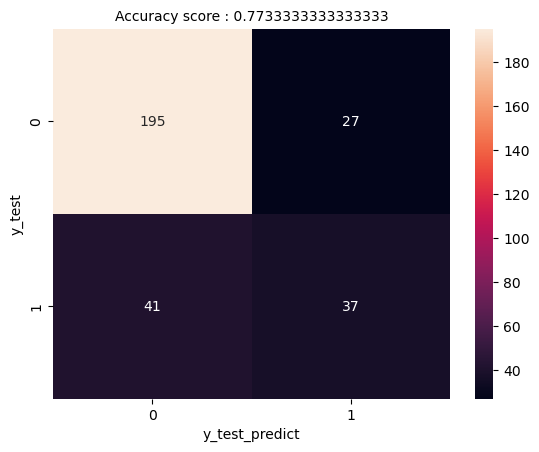

In [18]:
cm = confusion_matrix(test_df['stroke'], test_df['Predict'])

sns.heatmap(cm, annot = True, fmt = ".0f")
plt.xlabel('y_test_predict')
plt.ylabel('y_test')
plt.title('Accuracy score : {0}'.format(model_1_score), size = 10)

plt.show()

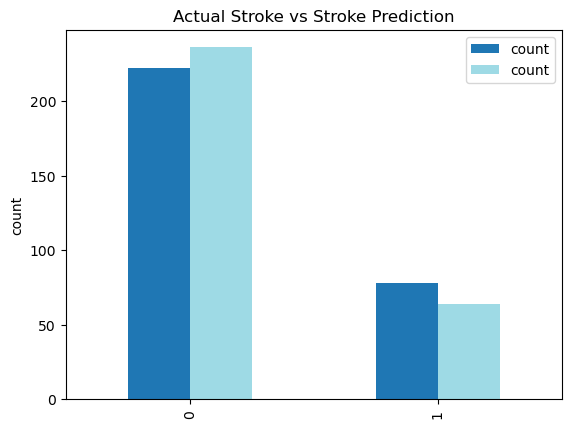

In [19]:
bar_chart = pd.concat([test_df['stroke'].value_counts(), test_df['Predict'].value_counts()], axis=1)

bar_chart.plot(kind='bar', colormap='tab20')
plt.title('Actual Stroke vs Stroke Prediction')
plt.ylabel('count')

plt.show()

## การทดลองที่ 2
##### การกำหนดค่า hyper parameter มีดังนี้

- ให้ alpha = 0.00005
- ให้ algorithm update weight คือ Stochastic Gradient Descent (sgd)
- ให้ Activation function คือ ReLu
- ให้ hidden layer ชั้นแรกมี 5 node ชั้นที่ 2 มี 3 node

In [20]:
model = MLPClassifier(activation='relu', solver='sgd', alpha=5e-1, hidden_layer_sizes=(5, 3), random_state=1)
model.fit(X_train, y_train)

c:\Users\trai 004\anaconda3\envs\ds\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,hidden_layer_sizes,"(5, ...)"
,activation,'relu'
,solver,'sgd'
,alpha,0.5
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,200
,shuffle,True
,random_state,1


In [21]:
y_pred = model.predict(X_test)
model_2_score = accuracy_score(y_pred, y_test)

model_2_score

0.74

In [22]:
test_df = pd.concat([X_test, y_test], axis=1)
test_df['Predict'] = y_pred

test_df

,FBS,BMI,Diabetes,Chorestorol,age,hypertension,"vegetarian (1= yes, 0=no)",Exercise (min/week),stroke,Predict
HN,,,,,,,,,,
34511,0.209525,0.246154,0.0,0.000000,0.806290,0,0,0.0,0,0
7663,0.238902,0.357692,1.0,0.875260,0.225160,0,0,0.5,0,0
23221,0.130537,0.475641,1.0,0.790021,0.327712,0,0,0.0,0,0
9404,0.240935,0.606410,0.0,0.790021,0.498633,0,0,0.0,0,0
45535,0.825396,0.543590,1.0,0.790021,0.772106,0,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...
48272,0.149014,0.312821,0.0,0.000000,0.122607,0,0,1.0,0,0
51983,0.073491,0.596154,0.0,1.000000,0.373291,0,0,0.0,0,0
55927,0.090766,0.284615,0.0,0.790021,0.908842,1,0,0.0,1,0


In [23]:
test_df[test_df['Predict'] == 1]

,FBS,BMI,Diabetes,Chorestorol,age,hypertension,"vegetarian (1= yes, 0=no)",Exercise (min/week),stroke,Predict
HN,,,,,,,,,,


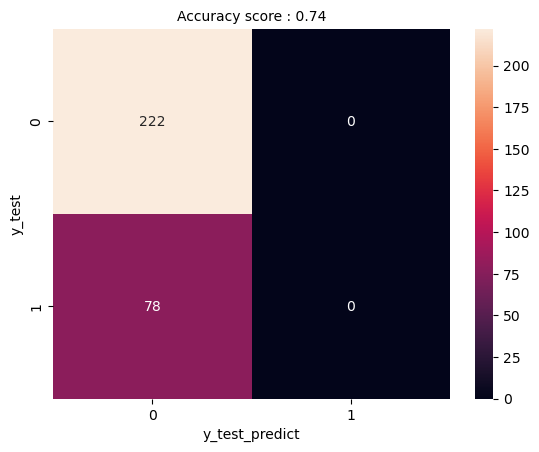

In [24]:
cm = confusion_matrix(test_df['stroke'], test_df['Predict'])

sns.heatmap(cm, annot = True, fmt = ".0f")
plt.xlabel('y_test_predict')
plt.ylabel('y_test')
plt.title('Accuracy score : {0}'.format(model_2_score), size = 10)

plt.show()

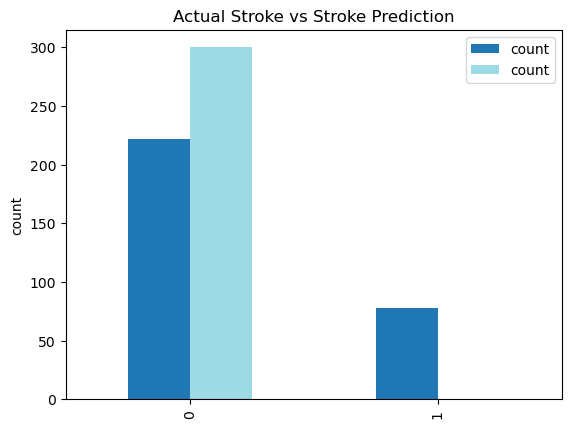

In [25]:
bar_chart = pd.concat([test_df['stroke'].value_counts(), test_df['Predict'].value_counts()], axis=1)

bar_chart.plot(kind='bar', colormap='tab20')
plt.title('Actual Stroke vs Stroke Prediction')
plt.ylabel('count')

plt.show()

## การทดลองที่ 3
##### การกำหนดค่า hyper parameter มีดังนี้

- ให้ alpha = 0.00005
- ให้ algorithm update weight คือ adam
- ให้ Activation function คือ ReLu
- ให้ hidden layer ชั้นแรกมี 5 node ชั้นที่ 2 มี 3 node

In [26]:
model = MLPClassifier(activation='relu', solver='adam', alpha=5e-1, hidden_layer_sizes=(5, 3), random_state=1)
model.fit(X_train, y_train)

c:\Users\trai 004\anaconda3\envs\ds\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,hidden_layer_sizes,"(5, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.5
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,200
,shuffle,True
,random_state,1


In [27]:
y_pred = model.predict(X_test)
model_3_score = accuracy_score(y_pred, y_test)

model_3_score

0.7666666666666667

In [28]:
test_df = pd.concat([X_test, y_test], axis=1)
test_df['Predict'] = y_pred

test_df

,FBS,BMI,Diabetes,Chorestorol,age,hypertension,"vegetarian (1= yes, 0=no)",Exercise (min/week),stroke,Predict
HN,,,,,,,,,,
34511,0.209525,0.246154,0.0,0.000000,0.806290,0,0,0.0,0,0
7663,0.238902,0.357692,1.0,0.875260,0.225160,0,0,0.5,0,0
23221,0.130537,0.475641,1.0,0.790021,0.327712,0,0,0.0,0,0
9404,0.240935,0.606410,0.0,0.790021,0.498633,0,0,0.0,0,0
45535,0.825396,0.543590,1.0,0.790021,0.772106,0,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...
48272,0.149014,0.312821,0.0,0.000000,0.122607,0,0,1.0,0,0
51983,0.073491,0.596154,0.0,1.000000,0.373291,0,0,0.0,0,0
55927,0.090766,0.284615,0.0,0.790021,0.908842,1,0,0.0,1,1


In [29]:
test_df[test_df['Predict'] == 1]

,FBS,BMI,Diabetes,Chorestorol,age,hypertension,"vegetarian (1= yes, 0=no)",Exercise (min/week),stroke,Predict
HN,,,,,,,,,,
36618,0.703912,0.391026,1.0,0.875260,0.851869,0,1,0.75,0,1
9648,0.534436,0.451282,0.0,0.790021,0.806290,0,1,0.00,0,1
14567,0.068548,0.356410,1.0,0.790021,0.840474,1,1,0.00,1,1
16685,0.643771,0.405128,0.0,0.790021,0.806290,1,0,0.00,0,1
28291,0.793247,0.382051,0.0,0.790021,0.897448,0,1,0.00,1,1
712,0.132939,0.339744,0.0,0.875260,0.931632,1,1,0.00,1,1
17013,0.266802,0.307692,1.0,0.790021,0.886053,1,0,0.00,1,1
65836,0.586401,0.391026,0.0,0.875260,0.886053,1,0,0.00,0,1
42786,0.081667,0.347436,1.0,0.875260,0.931632,0,1,0.75,0,1


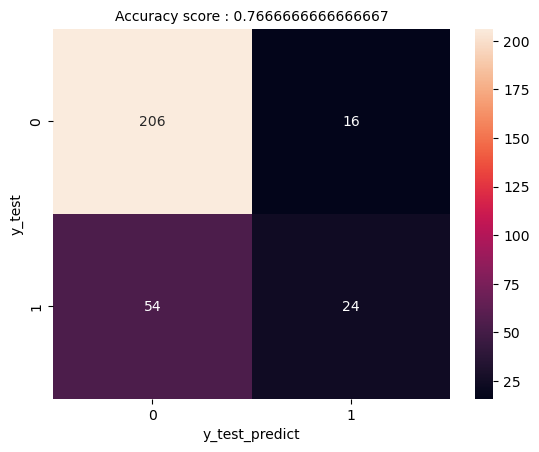

In [30]:
cm = confusion_matrix(test_df['stroke'], test_df['Predict'])

sns.heatmap(cm, annot = True, fmt = ".0f")
plt.xlabel('y_test_predict')
plt.ylabel('y_test')
plt.title('Accuracy score : {0}'.format(model_3_score), size = 10)

plt.show()

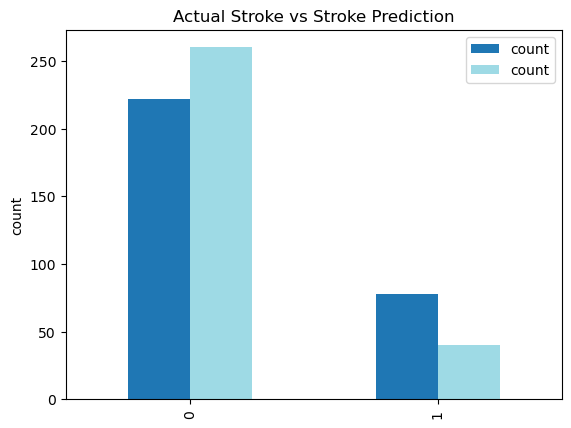

In [31]:
bar_chart = pd.concat([test_df['stroke'].value_counts(), test_df['Predict'].value_counts()], axis=1)

bar_chart.plot(kind='bar', colormap='tab20')
plt.title('Actual Stroke vs Stroke Prediction')
plt.ylabel('count')

plt.show()

# เปรียบเทียบทั้ง 3 การทดลอง

In [32]:
compare_chart = pd.DataFrame([model_1_score, model_2_score, model_3_score], index=['Model 1', 'Model 2', 'Model 3'], columns=['score'])
compare_chart

,score
Model 1,0.773333
Model 2,0.740000
Model 3,0.766667


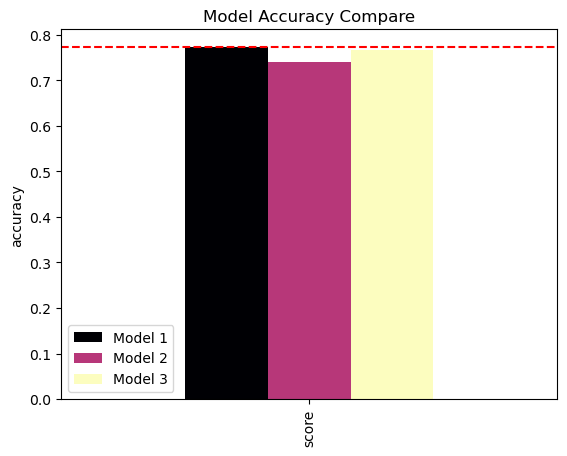

In [33]:
ax = compare_chart.T.plot(kind='bar', colormap='magma')
ax.axhline(y=model_1_score, linestyle='--', color='red')

plt.title('Model Accuracy Compare')
plt.ylabel('accuracy')

plt.show()